# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** Track A: Standard Analysis Project

**Group members:** 

- Victor Bjerggaard Thøstesen
- Nikolai Mose Sannerum  
- Frederik Hansen Baattrup  

**Dataset:** 

During the project we look at game statistics for Premier league matches since 2005. The datasets from 2003/2004 and 2004/2005 seasons are disregarded due to reading issues. 

Some features of the full datasets are combined into a master dataframe. This dataframe contains the features: "HomeTeam", "AwayTeam", "Full Time Result (FTR)", "Referee", "Full Time Home Goal (FTHG)", "Full Time Away Goal (FTAG)", "Home Shots (HS)", "Away Shots (AS)", "Home Shots On Target (HST)", "Away Shots On Target (AST)", "Home Fouls (HF)", "Away Fouls (AF)", "Home Corner (HC)", "Away Corner (AC)", "Home Yellow (HY)", "Away Yellow (Ay)", "Home Red (HR)", "Away Red (AR)", "Average Home Win Odds (AvgH)", "Average Draw Odds (AvgD)", "Average Away Win Odds (AvgA)", "Date" and "Season".

**Initial task description (Module 1 perspective):**

For the first part of the project we want to analyze our dataset using clustering. Our tentative analysis goal is to pick out a set of features from the dataset which can be meaningfully clustered and compared to a ground truth. First we apply unsupervised clustering to group football matches using in game statistics. The chosen features will be combined and transformed in order to reduce dimensions and make the matches more comparable. Outcome-related variables FTHG, FTAG, FTR, HTR and odds are excluded from clustering to prevent data leak and reserved for evaluation. After normalizing the numeric features, clustering algorithms are applied to identify match groupings. The FTR column serves as ground truth to assess alignment between clusters and actual outcomes (home win, away win, draw). Cluster evaluation metrics includes contingency tables and cluster purity measurements.


## 0. Reproducibility and Setup

In [26]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from tqdm import tqdm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.14.2 (main, Dec  5 2025, 16:49:16) [Clang 17.0.0 (clang-1700.6.3.2)]


## 1. Dataset Description and Loading

### Dataset Overview

- Source: https://www.football-data.co.uk/englandm.php?fbclid=IwY2xjawQVBq9leHRuA2FlbQIxMABicmlkETBhSDJ4V01maU9aZVJ1dkNsc3J0YwZhcHBfaWQQMjIyMDM5MTc4ODIwMDg5MgABHr9Bnmq21fRPvCUMfkcBIu9edZEMLrEi-QTbB8sBlRDK8vETlRUAA3XgndZg_aem_OCN-0ddvAe0Fob_1GlxMdg

- Number of instances (matches): 7860
- Number of features / entities: 23
- Missing values: No missing values after preprocessing. However when the seasons were combined we used only the average odds (provided by different websites for different seasons).


In [27]:
# --- Data Extraction Function ---
# Here we define a function to extract the chosen relevant data features from the raw CSV files.
# This function will look for the average odds columns and handle cases where they might be missing.

def extract_data(df, filename):
    """
    Extracts average in game features and home/draw/away odds from CSV file.
    Prefers BbAvH/D/A, otherwise falls back to AvgH/D/A.
    Adds season column extracted from filename.

    parameters:
    df: DataFrame containing the raw data from the CSV file.
    filename: The name of the CSV file, used to extract the season information.

    return: A DataFrame with the extracted features and season information, or None if required columns are missing.

    """

    primary_cols = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                  'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "BbAvH", "BbAvD", "BbAvA", 'Date']
    fallback_cols = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                  'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "AvgH", "AvgD", "AvgA", 'Date']

    season = os.path.splitext(filename)[0]

    # Trying to find Betbrain columns first
    if all(col in df.columns for col in primary_cols):
        result = df[primary_cols].copy()
        result.columns = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                            'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                            'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "AvgH", "AvgD", "AvgA", 'Date']
        print(f'Found primary columns: BbAvH, BbAvD, BbAvA for {filename}')

    # Else trying to find fallback columns
    elif all(col in df.columns for col in fallback_cols):
        result = df[fallback_cols].copy()
        print(f'Using fallback columns: AvgH, AvgD, AvgA for {filename}')

    # If neither set of columns is found, print a warning and return None
    else:
        print(f"⚠ Warning: Required odds columns not found in {filename}")
        return None

    # Add season column
    result["Season"] = season
    
    return result

In [28]:
# --- User settings begin ---
dataPath = "Data" # Define the folder where the raw CSV files are located.
# --- User settings end ---

new_data = []

for file in os.listdir(dataPath):
    if file.endswith(".csv"):
        path = os.path.join(dataPath, file)
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"⚠ Error reading {file}: {e}")
            continue

        extracted = extract_data(df, file)

        if extracted is not None:
            new_data.append(extracted)

# Combine everything into one dataframe
final_df = pd.concat(new_data, ignore_index=True)

Found primary columns: BbAvH, BbAvD, BbAvA for 20072008premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20112012premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20132014premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20242025premierleague.csv
⚠ Error reading 20042005premierleague.csv: 'utf-8' codec can't decode byte 0xa0 in position 75614: invalid start byte
Using fallback columns: AvgH, AvgD, AvgA for 20202021premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20192020premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20082009premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20062007premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20152016premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20222023premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20102011premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20092010premierleague.csv
Found primary 

In [29]:
print(f"\n Final dataset:")
final_df = final_df.dropna(subset=["HomeTeam", "AwayTeam"]) # 2014/2015 season has a row of NaN that is removed here
final_df


 Final dataset:


,HomeTeam,AwayTeam,FTR,Referee,FTHG,FTAG,HS,AS,HST,AST,...,AC,HY,AY,HR,AR,AvgH,AvgD,AvgA,Date,Season
0,Aston Villa,Liverpool,A,M Riley,1.0,2.0,10.0,17.0,6.0,7.0,...,2.0,4.0,2.0,0.0,0.0,3.67,3.23,1.95,11/08/07,20072008premierleague
1,Bolton,Newcastle,A,C Foy,1.0,3.0,13.0,7.0,9.0,5.0,...,3.0,1.0,1.0,0.0,0.0,2.41,3.18,2.80,11/08/07,20072008premierleague
2,Derby,Portsmouth,D,M Dean,2.0,2.0,12.0,12.0,5.0,6.0,...,6.0,1.0,2.0,0.0,0.0,2.85,3.19,2.38,11/08/07,20072008premierleague
3,Everton,Wigan,H,M Clattenburg,2.0,1.0,12.0,14.0,8.0,4.0,...,2.0,0.0,0.0,0.0,0.0,1.66,3.45,5.25,11/08/07,20072008premierleague
4,Middlesbrough,Blackburn,A,A Marriner,1.0,2.0,10.0,4.0,6.0,4.0,...,3.0,3.0,4.0,0.0,0.0,2.41,3.18,2.81,11/08/07,20072008premierleague
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7855,Hull,Man United,D,L Probert,0.0,0.0,16.0,7.0,6.0,1.0,...,1.0,2.0,2.0,0.0,1.0,3.14,3.55,2.21,24/05/15,20142015premierleague
7856,Leicester,QPR,H,M Oliver,5.0,1.0,22.0,18.0,7.0,2.0,...,6.0,0.0,0.0,0.0,0.0,1.56,4.21,5.71,24/05/15,20142015premierleague
7857,Man City,Southampton,H,C Foy,2.0,0.0,15.0,13.0,6.0,4.0,...,4.0,1.0,1.0,0.0,0.0,1.56,4.27,5.61,24/05/15,20142015premierleague
7858,Newcastle,West Ham,H,M Atkinson,2.0,0.0,17.0,4.0,4.0,1.0,...,3.0,2.0,1.0,0.0,0.0,1.77,3.84,4.42,24/05/15,20142015premierleague


In [30]:
def encode_results(results):
    """
    Endcoding of results
    1: HOME WIN, -1: AWAY WIN, 0: DRAW

    parameters:
    results (list of dicts): results to encode 

    returns:
    encoding (numpy array): encoded results
    """
    encoding = np.zeros(len(results)) # Initialize encoding array

    for i in range(len(results)):
        if results[i] == "H":
            encoding[i] = 1 # Home win
        elif results[i] == "A":
            encoding[i] = -1 # Away win
        else:
            encoding[i] = 0 # Draw
    return encoding
data = final_df.copy()
ground_truth = encode_results(data['FTR'])
print("Amount of home wins: ", np.sum(ground_truth == 1))
print("Amount of away wins: ", np.sum(ground_truth == -1))
print("Amount of draws: ", np.sum(ground_truth == 0))

Amount of home wins:  3586
Amount of away wins:  2368
Amount of draws:  1906


## Module 2 — Graph-Based Analysis

The networkx graph has been made as an directed graph, where the nodes are teams, while the edges are matches that points to the winning team, weighted by goal difference. If draw, the match is discarded, and if the same team win several matches, these matches are compressed into a single edge with the total goal difference as weight.

From the graph we construct an adjacency matrix where the [i, j] entry is the weight of the team j winning against team i. Note that entries with zeros correspond to either draws or a team that didn't win in any match. The teams are sorted in alphabetic order.

Stats: [ 0.70622015 -0.17655504  0.          0.52966511  0.17655504 -0.35664118
  0.         -0.17655504]
Weighted score: -0.17655503717285395
Stats: [-0.51156253 -0.51156253  0.07308036 -0.29232144  0.14616072 -0.59925896
 -0.07308036  0.        ]
Weighted score: 0.0
Stats: [-0.10741293  0.          0.64447761  0.64447761  0.10741293 -0.38239005
  0.          0.        ]
Weighted score: 0.0
Stats: [ 0.79733486  0.26577829  0.35437105  0.26577829  0.17718552 -0.1860448
  0.          0.17718552]
Weighted score: 0.17718552421506237
Stats: [ 0.         -0.56532976  0.         -0.18844325  0.18844325 -0.75754187
  0.          0.18844325]
Weighted score: 0.18844325199048573
Stats: [ 0.64270595 -0.10711766  0.64270595 -0.32135298 -0.10711766 -0.04177589
  0.         -0.21423532]
Weighted score: -0.21423531752930605
Stats: [ 0.79838323  0.11405475 -0.17108212  0.05702737  0.11405475 -0.53947896
  0.         -0.11405475]
Weighted score: -0.11405474753402106
Stats: [-0.848311   -0.14138517  0.4

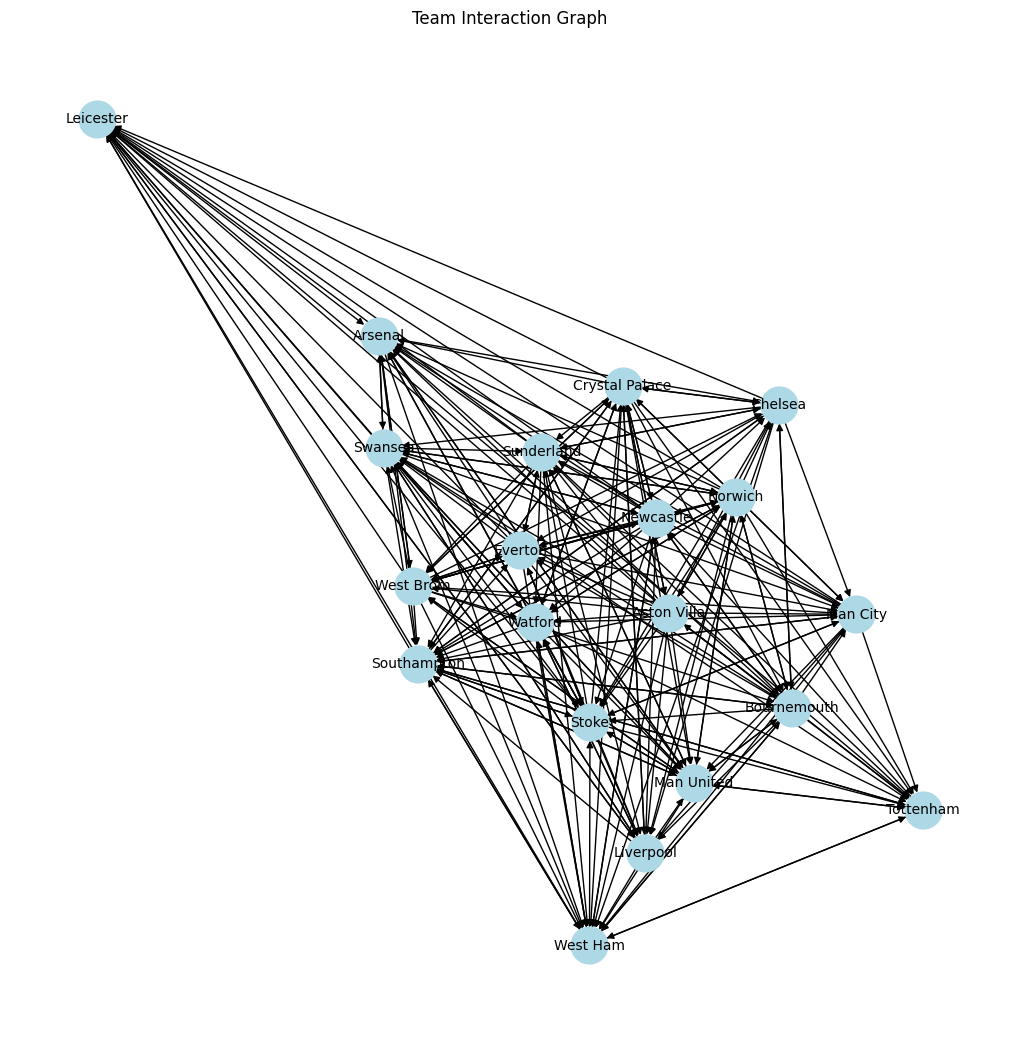

In [39]:
class DiG_edge:
    """Wrapper class for graph edges, containing source, target, and weight."""
    def __init__(self, Source: str, Target: str, weight: float):
        self.Source = Source
        self.Target = Target 
        self.weight = weight 

def weight_function(row, hyperparams):
    """
    Computes a weighted score for a match based on various statistics and the provided hyperparameters.
    The score is positive for the winning team with the graph edge directed from the losing team to the winning team.
    parameters:
        row: A row from the DataFrame containing match statistics.
        hyperparams: A list of weights for each statistic.

    returns:
        DiG_edge: An object containing the source team, target team, and the computed weight for the graph edge.    
    """
    stats = np.array([
        row['HS'] - row['AS'],     
        row['HST'] - row['AST'],   
        row['AF'] - row['HF'],   # Its bad to have more fouls than the opponent, so we subtract home from away  
        row['HC'] - row['AC'],     
        row['AY'] - row['HY'],     # More yellow cards than the opponent is bad, so we subtract home from away
        row['AvgH'] - row['AvgA'], 
        row['AR'] - row['HR'],     # More red cards than the opponent is bad, so we subtract home from away
        row['FTHG'] - row['FTAG']  
    ])
    # --- Normalization ---
    stats = stats / np.linalg.norm(stats)
    print(f"Stats: {stats}")
    weighted_score = np.sum(stats * hyperparams)
    print(f"Weighted score: {weighted_score}")
    
    if weighted_score > 0:
        return DiG_edge(row['AwayTeam'], row['HomeTeam'], weighted_score)
    elif weighted_score < 0:
        return DiG_edge(row['HomeTeam'], row['AwayTeam'], -weighted_score)
    else:
        return None

def create_and_plot_graph(edges: pd.Series, plot: bool = True):
    """
    Creates a directed graph from a Series of DiG_edge objects, where edges represent wins
    and are weighted by the computed score.

    parameters:
    edges (pd.Series): Series of DiG_edge objects (can contain None for draws/zero scores)
    plot (bool): Whether to plot the graph

    returns:
    G (DiGraph): Directed graph representing team interactions
    """
    # Filter out None values
    edges = [e for e in edges if e is not None]

    # Build DataFrame from edges
    edge_df = pd.DataFrame({
        'Source': [e.Source for e in edges],
        'Target': [e.Target for e in edges],
        'weight': [e.weight for e in edges]
    })

    # Aggregate weights if multiple edges exist between same teams
    edge_df = edge_df.groupby(['Source', 'Target'], as_index=False)['weight'].sum()

    # Build directed graph
    G = nx.from_pandas_edgelist(
        edge_df,
        source='Source',
        target='Target',
        edge_attr='weight',
        create_using=nx.DiGraph()
    )

    # Plot
    if plot:
        plt.figure(figsize=(10, 10))
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10)
        plt.title('Team Interaction Graph')
        plt.show()

    return G

# --- Usage ---
hyperparams = [0, 0, 0, 0, 0, 0, 0, 1]  # Example: only goal difference matters
weightGd = data.apply(lambda row: weight_function(row, hyperparams), axis=1)

# **Call the graph function only with the Series of DiG_edge**
G = create_and_plot_graph(weightGd)

In [40]:
nx.pagerank(G, weight='weight')

{'Arsenal': 0.09674512147392396,
 'Chelsea': 0.04936346816149961,
 'Man United': 0.06370200742080147,
 'Southampton': 0.09245618396432995,
 'Swansea': 0.040377989000035204,
 'West Brom': 0.030147735522353697,
 'West Ham': 0.062231476380455765,
 'Aston Villa': 0.011144245822255289,
 'Bournemouth': 0.04786735488302508,
 'Crystal Palace': 0.028179608883978066,
 'Everton': 0.044016861070014464,
 'Leicester': 0.07125073186082684,
 'Liverpool': 0.05712657227012577,
 'Man City': 0.05974545376298164,
 'Norwich': 0.027906155887775598,
 'Stoke': 0.0418517939646287,
 'Sunderland': 0.027854332865987562,
 'Tottenham': 0.059399527336272524,
 'Watford': 0.036222833249226837,
 'Newcastle': 0.05241054621950207}

In [38]:
# --- Construct the transition matrix ---
def construct_transition_matrix(G):
    A = nx.to_numpy_array(G, weight='GoalDifference', nodelist=sorted(G.nodes()))
    Delta = np.diag(A.sum(axis=1)) # Degree matrix (sum of rows)
    M = A.T @ np.linalg.inv(Delta) # Transition matrix (By O8-LinkAnalysis slide 19)
    return M
# --- Finding page rank by power iteration ---
def power_iteration(M, num_simulations: int, alpha: float = 0.85):
    """
    Power iteration method to find the dominant eigenvector of matrix M.
    (By O8-LinkAnalysis slide 22)

    parameters:
    M (numpy array): The matrix for which to compute the dominant eigenvector.
    num_simulations (int): The number of iterations to perform.

    returns:
    numpy array: The dominant eigenvector of M, normalized to sum to 1.
    """
    # Start with uniform vector
    b_k = np.ones(M.shape[1]) / M.shape[1] 
    
    new_M = alpha * M + (1 - alpha) / M.shape[1] * np.ones(M.shape) # Apply random teleports by slide 43 of O8-LinkAnalysis

    for _ in range(num_simulations):
        # Calculate the matrix-by-vector product
        
        b_k1 = new_M @ b_k
        
        # Normalize the resulting vector
        b_k1_norm = np.linalg.norm(b_k1)
        if b_k1_norm == 0:
            return b_k1  # Avoid division by zero
        b_k = b_k1 / b_k1_norm
    
    return b_k / np.sum(b_k)  # Normalize to sum to 1
def M_to_sorted_by_pagerank(M, G):
    pagerank_vector = power_iteration(M, num_simulations=1000)
    pagerank_scores = {node: score for node, score in zip(sorted(G.nodes()), pagerank_vector)}
    sorted_teams = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_teams
def print_pagerank_scores(sorted_teams):
    print("PageRank Scores:") 
    for team, score in sorted_teams:
        print(f"{team}: {score:.4f}")


In [33]:
M = construct_transition_matrix(G)       
print_pagerank_scores(M_to_sorted_by_pagerank(M, G))        

PageRank Scores:
West Ham: 0.0325
Man City: 0.0325
Man United: 0.0324
Arsenal: 0.0324
Everton: 0.0321
Chelsea: 0.0321
Tottenham: 0.0320
Liverpool: 0.0319
Aston Villa: 0.0318
Fulham: 0.0314
Newcastle: 0.0308
Sunderland: 0.0286
Wolves: 0.0280
West Brom: 0.0276
Burnley: 0.0262
Stoke: 0.0260
Southampton: 0.0260
Leicester: 0.0256
Crystal Palace: 0.0254
Bournemouth: 0.0254
Blackburn: 0.0244
Wigan: 0.0240
Watford: 0.0240
Brighton: 0.0230
Bolton: 0.0219
Brentford: 0.0219
Swansea: 0.0218
Middlesbrough: 0.0214
Norwich: 0.0212
Portsmouth: 0.0204
Hull: 0.0202
Sheffield United: 0.0190
Nott'm Forest: 0.0187
Leeds: 0.0186
Birmingham: 0.0159
QPR: 0.0158
Reading: 0.0148
Charlton: 0.0129
Cardiff: 0.0120
Huddersfield: 0.0098
Blackpool: 0.0097
Luton: 0.0076
Ipswich: 0.0064
Derby: 0.0041


This graph cares on how much you win a match where league table does not. this can probably be seen if checking 2015/2016 season where Leicester won.

In [34]:
data = data[data['Season'] == '20152016premierleague']
G = create_and_plot_graph(data, weightGd, plot=False)
M = construct_transition_matrix(G)
sorted_teams = M_to_sorted_by_pagerank(M, G)
print_pagerank_scores(sorted_teams)

TypeError: create_and_plot_graph() got multiple values for argument 'plot'

Maybe there is some kind of data leak here since the analysis basically is based on full time result. Lets generalize how we calculate the weights 